# Length correction robustness

Robustness of the sign-reversal result to alternative length-correction
parametrisations and to the choice of reasoning-phase prefix cut, plus the
residual diagnostic for the canonical cubic-log fit.

In [1]:
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 120,
})

DATA = Path('data/processed')
OUT_FIGS = Path('figures')
OUT_FIGS.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ['code', 'math', 'sat']
DOMAIN_LABEL = {'code': 'Code', 'math': 'Math', 'sat': 'SAT'}
PAPER_LABEL = {
    'deepseek-r1-7b': 'DS-R1-7B', 'deepseek-r1-14b': 'DS-R1-14B',
    'deepseek-r1-32b': 'DS-R1-32B', 'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'R1-Llama-8B', 'phi-4-reasoning': 'Phi-4-R',
    'qwen-7b': 'Qwen-7B', 'qwen-14b': 'Qwen-14B', 'qwen-32b': 'Qwen-32B',
    'llama-8b': 'Llama-8B', 'phi-4': 'Phi-4',
}
REASONING_ORDER = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'qwq-32b', 'r1-distill-llama-8b', 'phi-4-reasoning']
BASELINE_ORDER = ['qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
MODEL_ORDER = REASONING_ORDER + BASELINE_ORDER
PAPER_LABELS = [PAPER_LABEL[m] for m in MODEL_ORDER]


## Generate analysis inputs

When `IRT_RESULTS_ROOT` points at a populated `data/results/` tree, the cells
below regenerate `data/processed/03_*.parquet` from per-model
`trajectory_summaries.parquet` and `data/results/segmentation_validation/`.


In [2]:
# >>> generation-marker <<<
import numpy as np
from scipy.stats import spearmanr

RESULTS = Path(os.environ.get('IRT_RESULTS_ROOT', 'data/results'))
PROCESSED = Path('data/processed')
REGEN = RESULTS.exists() and any(RESULTS.rglob('trajectories/trajectory_summaries.parquet'))
print(f'regenerate from raw? {REGEN}  (IRT_RESULTS_ROOT={RESULTS})')


regenerate from raw? False  (IRT_RESULTS_ROOT=data/results)


### Six length-correction methods


In [3]:
# Build 03_length_correction_variants.parquet by applying 6 length-correction
# methods to each metric per (pair, role, model, domain). Long format. Each correlation
# is computed per layer and reported as the MEDIAN ACROSS the 5 sampled layers.
HIDDEN_STATE_MODELS = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                      'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning',
                      'qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
REASONING = set(HIDDEN_STATE_MODELS[:6])
PAIR_LABEL = {
    'deepseek-r1-7b': 'Qwen-7B', 'qwen-7b': 'Qwen-7B',
    'deepseek-r1-14b': 'Qwen-14B', 'qwen-14b': 'Qwen-14B',
    'deepseek-r1-32b': 'Qwen-32B', 'qwen-32b': 'Qwen-32B',
    'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'Llama-8B', 'llama-8b': 'Llama-8B',
    'phi-4-reasoning': 'Phi-4', 'phi-4': 'Phi-4',
}
METRICS = {'D': 'directness', 'V': 'curvature_std', 'T': 'twonn_dim', 'P': 'pca_dim_90'}
METHODS = ['raw', 'log', 'invsqrt', 'loglog', 'cubic-log', 'binned']

def _correct(y, n_tokens, method):
    """Length-correct y given n_tokens. Returns residual."""
    log_n = np.log(n_tokens)
    if method == 'raw':
        return y
    if method == 'log':
        x = log_n
    elif method == 'invsqrt':
        x = 1.0 / np.sqrt(n_tokens)
    elif method == 'loglog':
        # log Y ~ log N; subtract that linear part
        ly = np.log(np.maximum(y, 1e-12))
        X = np.column_stack([np.ones_like(log_n), log_n])
        coef, *_ = np.linalg.lstsq(X, ly, rcond=None)
        return np.exp(ly - X @ coef)
    elif method == 'cubic-log':
        x = np.column_stack([log_n, log_n**2, log_n**3])
    elif method == 'binned':
        bins = pd.qcut(log_n, q=5, labels=False, duplicates='drop')
        out = np.empty_like(y, dtype=float)
        for b in np.unique(bins):
            mask = bins == b
            out[mask] = y[mask] - y[mask].mean()
        return out
    else:
        raise ValueError(method)
    if x.ndim == 1:
        X = np.column_stack([np.ones_like(x), x])
    else:
        X = np.column_stack([np.ones(len(x)), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ coef

if REGEN:
    diffs = pd.read_parquet(PROCESSED / '01_difficulties.parquet').copy()
    diffs['domain'] = diffs['item_id'].str.split('_', n=1).str[0]
    diffs['problem_id'] = diffs['item_id'].str.split('_', n=1).str[1]
    diff_map = diffs.set_index(['domain', 'problem_id'])['difficulty']
    rows = []
    for model in HIDDEN_STATE_MODELS:
        for dom in DOMAIN_ORDER:
            p = RESULTS / dom / model / 'trajectories' / 'trajectory_summaries.parquet'
            if not p.exists():
                continue
            df = pd.read_parquet(p)
            layer_aggs = []
            for L in sorted(df['layer'].unique()):
                agg = (df[df['layer'] == L]
                       .groupby('problem_id')
                       .agg({c: 'mean' for c in METRICS.values()} | {'n_tokens': 'mean'})
                       .reset_index())
                agg['difficulty'] = agg['problem_id'].map(lambda pid: diff_map.get((dom, pid), np.nan))
                layer_aggs.append(agg.dropna(subset=['difficulty']))
            n_problems = len(layer_aggs[-1]) if layer_aggs else 0
            for metric_key, col in METRICS.items():
                for method in METHODS:
                    vals = []
                    for agg in layer_aggs:
                        y = agg[col].astype(float).values
                        if len(y) < 10 or np.isnan(y).any():
                            continue
                        n_tokens = agg['n_tokens'].astype(float).values
                        diff_v = agg['difficulty'].astype(float).values
                        vals.append(spearmanr(_correct(y, n_tokens, method), diff_v)[0])
                    if not vals:
                        continue
                    rows.append({
                        'pair': PAIR_LABEL[model],
                        'role': 'r1' if model in REASONING else 'base',
                        'model': model, 'domain': dom,
                        'n': int(n_problems),
                        'metric': metric_key, 'method': method,
                        'rho_perp': float(np.median(vals)),
                    })
    pd.DataFrame(rows).to_parquet(PROCESSED / '03_length_correction_variants.parquet', index=False)
    print(f'rebuilt 03_length_correction_variants.parquet ({len(rows)} rows, median across layers)')
else:
    print('using shipped 03_length_correction_variants.parquet')

using shipped 03_length_correction_variants.parquet


### Prefix sensitivity


In [4]:
# Copy segmentation prefix-sensitivity from upstream aggregation.
if REGEN:
    src = RESULTS / 'segmentation_validation' / 'sensitivity_rho.parquet'
    if src.exists():
        pd.read_parquet(src).to_parquet(PROCESSED / '03_prefix_sensitivity.parquet', index=False)
        print(f'copied {src.name} -> 03_prefix_sensitivity.parquet')
    else:
        print(f'segmentation_validation not found at {src}; using shipped cache')
else:
    print('using shipped 03_prefix_sensitivity.parquet')


using shipped 03_prefix_sensitivity.parquet


### Cubic-log residual diagnostics


In [5]:
# Cubic-log residuals for deepseek-r1-7b on code at peak layer.
if REGEN:
    p = RESULTS / 'code' / 'deepseek-r1-7b' / 'trajectories' / 'trajectory_summaries.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        peak = int(df['layer'].max())
        df = df[df['layer'] == peak]
        agg = df.groupby('problem_id').agg({c: 'mean' for c in METRICS.values()} | {'n_tokens': 'mean'}).reset_index()
        log_n = np.log(agg['n_tokens'].astype(float).values)
        rows = []
        for label, col in [('Directness', 'directness'), ('Curvature std', 'curvature_std'),
                            ('TwoNN dim', 'twonn_dim'), ('PCA-90', 'pca_dim_90')]:
            y = agg[col].astype(float).values
            coef = np.polyfit(log_n, y, deg=3)
            resid = y - np.polyval(coef, log_n)
            rho, _ = spearmanr(resid, log_n)
            for ln, r in zip(log_n, resid):
                rows.append({'metric': label, 'log_n': float(ln), 'residual': float(r),
                             'spearman_rho': float(rho)})
        pd.DataFrame(rows).to_parquet(PROCESSED / '03_residual_diagnostics.parquet', index=False)
        print(f'rebuilt 03_residual_diagnostics.parquet ({len(rows)} rows)')
    else:
        print(f'r1-7b code summary not found; using shipped cache')
else:
    print('using shipped 03_residual_diagnostics.parquet')


using shipped 03_residual_diagnostics.parquet


---


## Length correction comparison (`length_correction.pdf`)

For each (pair, role, domain, metric), ρ⟂ under four length-correction families.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


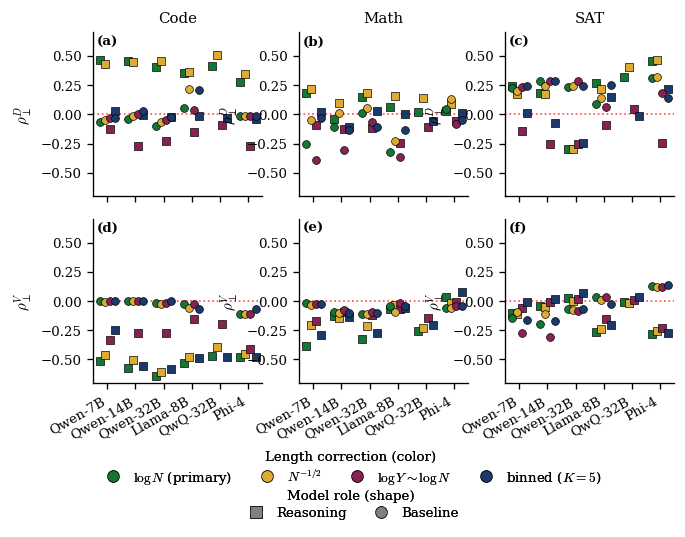

In [6]:
df_v = pd.read_parquet(DATA / '03_length_correction_variants.parquet')

METHODS = ['log', 'invsqrt', 'loglog', 'binned']
METHOD_LABEL = {'log': r'$\log N$ (primary)', 'invsqrt': r'$N^{-1/2}$',
                'loglog': r'$\log Y\sim\log N$', 'binned': r'binned ($K{=}5$)'}
METHOD_COLOUR = {'log': '#117733', 'invsqrt': '#DDAA33',
                 'loglog': '#882255', 'binned': '#1B3A6B'}
PAIR_ORDER = ['Qwen-7B', 'Qwen-14B', 'Qwen-32B', 'Llama-8B', 'QwQ-32B', 'Phi-4']
TARGETS = ['D', 'V']
METHOD_X_OFFSET = {m: (j - 1.5) * 0.18 for j, m in enumerate(METHODS)}
role_marker = {'base': 'o', 'r1': 's'}

fig = plt.figure(figsize=(5.5, 4.0))
gs = fig.add_gridspec(2, len(DOMAIN_ORDER), wspace=0.22, hspace=0.14,
                      left=0.11, right=0.99, bottom=0.22, top=0.95)
axes = [[fig.add_subplot(gs[r, c]) for c in range(len(DOMAIN_ORDER))] for r in range(2)]
panel_lbls = [[f'({chr(97 + r * len(DOMAIN_ORDER) + c)})' for c in range(len(DOMAIN_ORDER))]
              for r in range(2)]

for ri, tlbl in enumerate(TARGETS):
    for ci, dom in enumerate(DOMAIN_ORDER):
        ax = axes[ri][ci]
        ax.axhline(0, color='red', linestyle=':', linewidth=1.0, alpha=0.7, zorder=2)
        sub = df_v[(df_v['metric'] == tlbl) & (df_v['domain'] == dom) & (df_v['method'].isin(METHODS))]
        for _, r in sub.iterrows():
            if r['pair'] not in PAIR_ORDER:
                continue
            pair_x = PAIR_ORDER.index(r['pair'])
            ax.scatter(pair_x + METHOD_X_OFFSET[r['method']], r['rho_perp'],
                       s=22, c=METHOD_COLOUR[r['method']], marker=role_marker[r['role']],
                       edgecolors='black', linewidths=0.4, zorder=5)
        ax.set_xticks(range(len(PAIR_ORDER)))
        if ri == 0:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(PAIR_ORDER, rotation=30, ha='right')
        ax.set_xlim(-0.5, len(PAIR_ORDER) - 0.5)
        ax.set_ylabel(rf'$\rho_\perp^{tlbl}$')
        if ri == 0:
            ax.set_title(DOMAIN_LABEL[dom])
        ax.set_ylim(-0.7, 0.7)
        ax.text(0.022, 0.985, panel_lbls[ri][ci], transform=ax.transAxes,
                fontsize=8, fontweight='bold', va='top', ha='left')

method_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=METHOD_COLOUR[m],
                             markeredgecolor='black', markeredgewidth=0.4, markersize=7,
                             label=METHOD_LABEL[m]) for m in METHODS]
role_handles = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='black',
               markeredgewidth=0.4, markersize=7, label='Reasoning'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black',
               markeredgewidth=0.4, markersize=7, label='Baseline'),
]
leg_method = fig.legend(handles=method_handles, title='Length correction (color)',
                        loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02),
                        fontsize=8, title_fontsize=8, labelspacing=0.3, handletextpad=0.5,
                        columnspacing=1.6)
leg_role = fig.legend(handles=role_handles, title='Model role (shape)',
                      loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.09),
                      fontsize=8, title_fontsize=8, labelspacing=0.3, handletextpad=0.5,
                      columnspacing=1.6)
fig.add_artist(leg_method)
fig.add_artist(leg_role)

fig.savefig(OUT_FIGS / 'length_correction.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'length_correction.png', dpi=300, bbox_inches='tight')
plt.show()


## Cubic-log residual diagnostics (`cubic_log_residuals.pdf`)

Residuals after a cubic-log fit for the canonical deepseek-r1-7b code run at peak layer 13.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


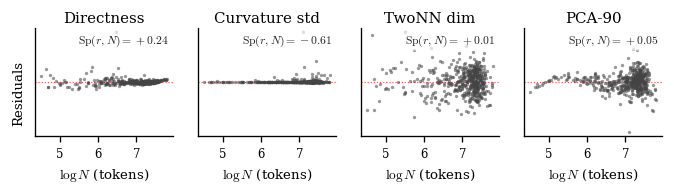

In [7]:
df_r = pd.read_parquet(DATA / '03_residual_diagnostics.parquet')
metrics_order = ['Directness', 'Curvature std', 'TwoNN dim', 'PCA-90']

fig, axes = plt.subplots(1, 4, figsize=(5.5, 1.55), sharex=True)
for ax, m in zip(axes, metrics_order):
    sub = df_r[df_r['metric'] == m]
    rho = sub['spearman_rho'].iloc[0]
    ax.axhline(0, color='red', linestyle=':', linewidth=0.7, alpha=0.7, zorder=1)
    ax.scatter(sub['log_n'], sub['residual'], s=4.0, color='#444', alpha=0.55, linewidths=0, zorder=2)
    ax.text(0.97, 0.95, rf'$\mathrm{{Sp}}(r,N){{=}}{rho:+.2f}$',
            transform=ax.transAxes, ha='right', va='top', fontsize=7, color='#222',
            bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.7))
    lim = float(np.max(np.abs(sub['residual'].values))) * 1.08
    ax.set_ylim(-lim, lim)
    ax.set_yticks([])
    ax.set_title(m, fontsize=9, pad=3)
    ax.set_xlabel(r'$\log N$ (tokens)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

fig.supylabel('Residuals', fontsize=8, x=0.005)
fig.subplots_adjust(left=0.04, right=0.99, top=0.85, bottom=0.27, wspace=0.18)
fig.savefig(OUT_FIGS / 'cubic_log_residuals.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'cubic_log_residuals.png', dpi=300, bbox_inches='tight')
plt.show()


## Directness prefix sensitivity (`directness_prefix_sensitivity.pdf`)

ρ vs reasoning-phase prefix fraction τ, averaged within five matched pair-groups.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


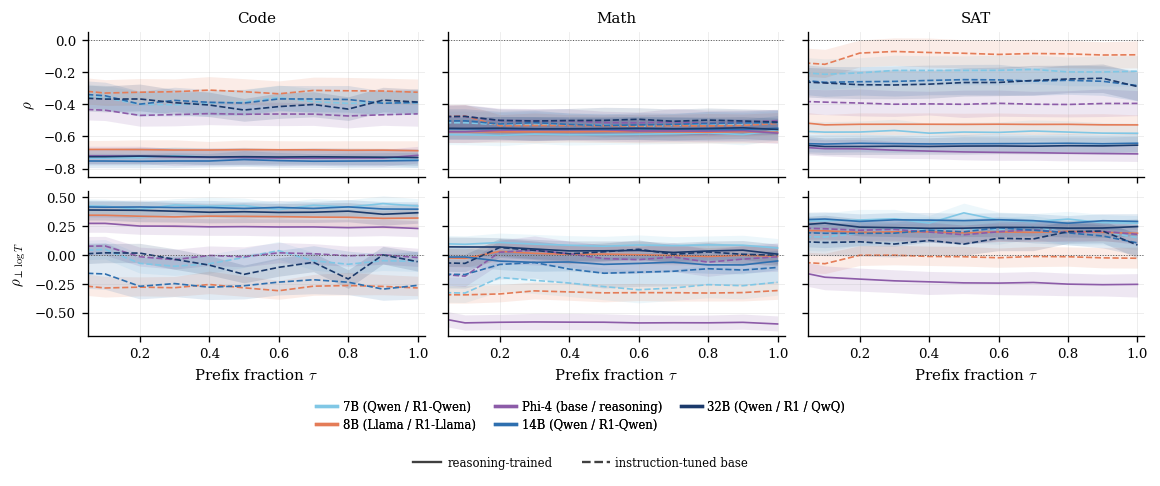

In [8]:
df_s = pd.read_parquet(DATA / '03_prefix_sensitivity.parquet')

# Architecture-group colors match the paper's PAIR_COLOR palette.
PAIR_GROUPS = {
    '7B (Qwen / R1-Qwen)':   {'r1': ['deepseek-r1-7b'], 'base': ['qwen-7b'], 'color': '#80C7E5'},
    '8B (Llama / R1-Llama)': {'r1': ['r1-distill-llama-8b'], 'base': ['llama-8b'], 'color': '#E47C57'},
    'Phi-4 (base / reasoning)': {'r1': ['phi-4-reasoning'], 'base': ['phi-4'], 'color': '#8C5BA8'},
    '14B (Qwen / R1-Qwen)':  {'r1': ['deepseek-r1-14b'], 'base': ['qwen-14b'], 'color': '#2E6FAF'},
    '32B (Qwen / R1 / QwQ)': {'r1': ['deepseek-r1-32b', 'qwq-32b'], 'base': ['qwen-32b'], 'color': '#1B3A6B'},
}
METHOD_ROWS = [('raw', r'$\rho$', (-0.85, 0.05)),
               ('logtok', r'$\rho_{\perp\,\log T}$', (-0.7, 0.55))]

fig, axes = plt.subplots(2, len(DOMAIN_ORDER),
                         figsize=(3.25 * len(DOMAIN_ORDER), 4.0),
                         sharex=True, sharey='row')
for row, (method, ylabel, ylim) in enumerate(METHOD_ROWS):
    for col, dom in enumerate(DOMAIN_ORDER):
        ax = axes[row, col]
        for label, info in PAIR_GROUPS.items():
            for role, ls in [('r1', '-'), ('base', '--')]:
                sub = df_s[(df_s['domain'] == dom) & (df_s['model'].isin(info[role]))
                           & (df_s['method'] == method)]
                if sub.empty:
                    continue
                grp = sub.groupby('frac', as_index=False)[['rho', 'lo', 'hi']].mean()
                ax.plot(grp['frac'], grp['rho'], ls=ls, color=info['color'], lw=1.0)
                ax.fill_between(grp['frac'], grp['lo'], grp['hi'], color=info['color'],
                                alpha=0.14, lw=0)
        ax.axhline(0, color='0.35', linestyle=':', linewidth=0.6)
        ax.set_xlim(0.05, 1.02)
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.25, linewidth=0.5)
        if row == 0:
            ax.set_title(DOMAIN_LABEL[dom])
        if row == 1:
            ax.set_xlabel(r'Prefix fraction $\tau$')
    axes[row, 0].set_ylabel(ylabel)

color_handles = [plt.Line2D([0], [0], color=info['color'], lw=2.0, ls='-', label=label)
                 for label, info in PAIR_GROUPS.items()]
style_handles = [plt.Line2D([0], [0], color='0.25', lw=1.4, ls='-', label='reasoning-trained'),
                 plt.Line2D([0], [0], color='0.25', lw=1.4, ls='--', label='instruction-tuned base')]

fig.tight_layout(h_pad=0.6, w_pad=0.8, rect=(0, 0.16, 1, 1))
leg_color = fig.legend(handles=color_handles, loc='lower center', bbox_to_anchor=(0.5, 0.07),
                       ncol=3, frameon=False, handlelength=1.8, columnspacing=1.6,
                       handletextpad=0.5, labelspacing=0.4)
fig.legend(handles=style_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
           ncol=2, frameon=False, handlelength=2.4, columnspacing=2.5, handletextpad=0.5)
fig.add_artist(leg_color)

fig.savefig(OUT_FIGS / 'directness_prefix_sensitivity.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'directness_prefix_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()


## Per-method ρ⟂ summary


In [9]:
summary = df_v[df_v['metric'] == 'D'].pivot_table(
    index=['pair', 'role'], columns='method', values='rho_perp'
).round(3)
print(summary.to_string())


method         binned  cubic-log  invsqrt    log  loglog    raw
pair     role                                                  
Llama-8B base   0.110      0.168    0.044 -0.063  -0.087 -0.207
         r1     0.043      0.067    0.244  0.231  -0.161 -0.512
Phi-4    base   0.025      0.072    0.146  0.115   0.029 -0.380
         r1     0.066     -0.009    0.302  0.252  -0.192 -0.604
QwQ-32B  r1    -0.033     -0.016    0.351  0.252  -0.051 -0.641
Qwen-14B base   0.059      0.078    0.079  0.046  -0.005 -0.255
         r1    -0.059     -0.159    0.238  0.200  -0.218 -0.624
Qwen-32B base   0.039      0.064    0.077  0.048   0.056 -0.297
         r1    -0.080     -0.098    0.114  0.085  -0.203 -0.537
Qwen-7B  base   0.058      0.078    0.036 -0.032  -0.064 -0.246
         r1     0.020      0.038    0.273  0.298  -0.120 -0.591
